**EcoReward – Waste Image Classification (MVP)**

This notebook trains a simple image classification model to identify waste types
(plastic, paper, metal, glass, organic, electronic, unsorted) for EcoReward’s
AI-assisted waste verification system.

The goal is **demonstration and validation**, not high-accuracy production AI.

**DATA PREPARATION**

In [1]:
#1 mount google drive to access the EcoReward dataset stored

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#2 define dataset directory paths that points to the training and validation image folders

import os

base_dir = "/content/drive/MyDrive/Machine_Learning_Journey/EcoReward_Dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "validation")

In [3]:
#3a chaeck how many images exist per class to understand class imbalance and confirms data loading (Training Images)

for class_name in os.listdir(train_dir):
  class_path = os.path.join(train_dir, class_name)
  print(f"{class_name}: {len(os.listdir(class_path))} training images")

plastic: 80 training images
paper: 80 training images
metal: 80 training images
glass: 80 training images


In [4]:
#3b chaeck how many images exist per class to understand class imbalance and confirms data loading (Validation Images)

for class_name in os.listdir(val_dir):
  class_path = os.path.join(val_dir, class_name)
  print(f"{class_name}: {len(os.listdir(class_path))} validation images")

plastic: 20 validation images
paper: 20 validation images
glass: 20 validation images
metal: 20 validation images


In [5]:
#4 import required lbraries
# TensorFlow/Keras handles the deep learning
# Matplotlib is used for visualization
# Numpy supports numerical operations

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

**DATA GENERATORS**

In [6]:
#5 create image data generators to handle image loading, resizing, normalization, and augmentation

img_size = (224, 224)
batch_size = 16

train_generator = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_generator = ImageDataGenerator(
    rescale=1.0/255
)

In [7]:
#6a load images from directories
# keras assigns labels based on folder names

train_data = train_generator.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_data = validation_generator.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

Found 311 images belonging to 4 classes.
Found 75 images belonging to 4 classes.


In [8]:
#6b create validation data generator
# validation data should NOT be augmented

val_datagen = ImageDataGenerator(
    rescale=1./255
)

# load validation images from directory

val_generator = val_datagen.flow_from_directory(
    val_dir,                                              # Path to validation data
    target_size=(224, 224),                               # Image size expected by the model
    batch_size=32,
    class_mode='categorical'                              # Multi-class classification
)

Found 75 images belonging to 4 classes.


**BASE MODEL LOADING**

In [9]:
#7 load MobileNetV2 as the base model (pre-trained on ImageNet)
# this exclude the top layers because we will add our own classifier

from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**FREEZING LAYERS**

In [10]:
#8 freeze all layers in the base model so they are not trained

base_model.trainable = False

**MODEL ARCHITECTURE SETUP**

In [11]:
#9 build the full model by adding a custom classification head

from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,                                   # Feature extractor
    layers.GlobalAveragePooling2D(),              # Reduce feature maps
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),                          # Prevents overfitting
    layers.Dense(4, activation='softmax')         # 4 waste classes
])

**MODEL COMPILATION**

In [12]:
#10 compile the model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**MODEL SUMMARY**

In [13]:
#11 summarize model structure so far

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**MODEL TRAINING**

In [14]:
#12 train the model on the training dataset
# validation data is used to monitor performance on unseen data

history = model.fit(
    train_data,                      # Training data generator
    validation_data=val_data,        # Validation data generator
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 163s 7s/step - accuracy: 0.5595 - loss: 1.1169 - val_accuracy: 0.6533 - val_loss: 0.7143
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.8842 - loss: 0.4275 - val_accuracy: 0.7467 - val_loss: 0.6039
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.8971 - loss: 0.2993 - val_accuracy: 0.8000 - val_loss: 0.5615
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.9260 - loss: 0.2342 - val_accuracy: 0.8133 - val_loss: 0.4816
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9646 - loss: 0.1131 - val_accuracy: 0.8000 - val_loss: 0.5152
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9711 - loss: 0.1116 - val_accuracy: 0.7600 - val_loss: 0.5687
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.9678 - loss: 0.1313 - val_accuracy: 0.7733 - val_loss: 0.5467
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9614 - loss: 0.1120 - val_accuracy: 0.8133 - val_loss

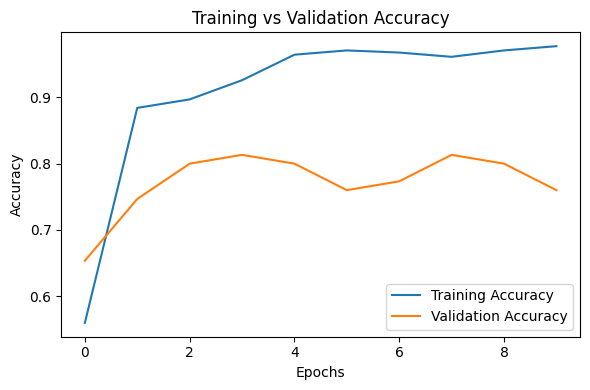

In [43]:
#13 plot training and validation accuracy

plt.figure(figsize=(6,4))

# extract accuracy values from training history

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
#14 view history values

history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [17]:
#15 save trained model in keras native format for later use

model.save("waste_classifier_v2.keras")

In [18]:
#16 import load_model to reload a saved keras model

from tensorflow.keras.models import load_model

# load the previously saved trained model

model = load_model("waste_classifier_v2.keras")

In [19]:
#17 evaluate the model performance on the validation dataset

model.evaluate(val_generator)

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7600 - loss: 0.6382


[0.6382253766059875, 0.7599999904632568]

In [20]:
#18 load and preprocess a single image for prediction (glass)

from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/drive/MyDrive/Machine_Learning_Journey/EcoReward_Test_Dataset/glass/download.jpg"
img = image.load_img(
    img_path,
    target_size=(224, 224)      # use the same size you trained with
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [21]:
# run the trained model on the inpute image to get prediction probabilities

prediction = model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[0.8938918  0.00121973 0.00364902 0.10123942]]


In [22]:
# get the index of the class with the highest prediction probability

predicted_class = np.argmax(prediction, axis=1)
confidence = np.max(prediction)

In [23]:
# display the predicted class index & confidence score

print("Predicted class index:", predicted_class[0])
print("Confidence:", confidence)

Predicted class index: 0
Confidence: 0.8938918


In [24]:
# retrieve the mapping of class names to numerical indicies

class_indices = val_generator.class_indices

# convert class indicies back to human-readable class labels

reversed_class_labels = {v: k for k, v in class_indices.items()}

# display the predicted waste category

print("Predicted label:", reversed_class_labels[predicted_class[0]])

Predicted label: glass


In [25]:
#19 load and preprocess a single image for prediction (metal)

img_path = "/content/drive/MyDrive/Machine_Learning_Journey/EcoReward_Test_Dataset/metal/SCRAP COMPRESSORS.jpg"
img = image.load_img(
    img_path,
    target_size=(224, 224)      # use the same size you trained with
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [26]:
# run the trained model on the inpute image to get prediction probeailities

prediction2 = model.predict(img_array)
print(prediction2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
[[3.5108815e-04 9.9864131e-01 6.0478873e-05 9.4710314e-04]]


In [27]:
# get the index of the class with the highest prediction probability

predicted_class = np.argmax(prediction2, axis=1)
confidence = np.max(prediction2)

In [28]:
# display the predicted class index & confidence score

print("Predicted class index:", predicted_class[0])
print("Confidence:", confidence)

Predicted class index: 1
Confidence: 0.9986413


In [29]:
# retrieve the mapping of class names to numerical indicies

class_indices = val_generator.class_indices

# convert class indicies back to human-readable class labels

reversed_class_labels = {v: k for k, v in class_indices.items()}

# display the predicted waste category

print("Predicted label:", reversed_class_labels[predicted_class[0]])

Predicted label: metal


In [30]:
#20 load and preprocess a single image for prediction (paper)

img_path = "/content/drive/MyDrive/Machine_Learning_Journey/EcoReward_Test_Dataset/paper/Metallic Print Color Wrapping Paper Translucent Wrapping Paper Tissue Paper Craft Paper Gift Wrapping Tissue Paper Bulk For Art Craft Floral Birthday Party Festival Gift Wrap Art Crafts Diy Pack Bags 20x14 20 Sheets .jpg"
img = image.load_img(
    img_path,
    target_size=(224, 224)      # use the same size you trained with
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [31]:
# run the trained model on the inpute image to get prediction probabilities

prediction3 = model.predict(img_array)
print(prediction3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
[[0.04126621 0.2556614  0.6978714  0.00520101]]


In [32]:
# get the index of the class with the highest prediction probability

predicted_class = np.argmax(prediction3, axis=1)
confidence = np.max(prediction3)

In [33]:
# display the predicted class index & confidence score

print("Predicted class index:", predicted_class[0])
print("Confidence:", confidence)

Predicted class index: 2
Confidence: 0.6978714


In [34]:
# retrieve the mapping of class names to numerical indicies

class_indices = val_generator.class_indices

# convert class indicies back to human-readable class labels

reversed_class_labels = {v: k for k, v in class_indices.items()}

# display the predicted waste category

print("Predicted label:", reversed_class_labels[predicted_class[0]])

Predicted label: paper


In [35]:
#21 load and preprocess a single image for prediction (plastic)

img_path = "/content/drive/MyDrive/Machine_Learning_Journey/EcoReward_Test_Dataset/plastic/For a Healthier Trip, Avoid This Common Mistake _ Porthole Cruise.jpg"
img = image.load_img(
    img_path,
    target_size=(224, 224)      # use the same size you trained with
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [36]:
# run the trained model on the inpute image to get prediction probabilities

prediction4 = model.predict(img_array)
print(prediction4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
[[2.8108590e-04 1.2048517e-04 2.6380029e-04 9.9933463e-01]]


In [37]:
# get the index of the class with the highest prediction probability

predicted_class = np.argmax(prediction4, axis=1)
confidence = np.max(prediction4)

In [38]:
# display the predicted class index & confidence score

print("Predicted class index:", predicted_class[0])
print("Confidence:", confidence)

Predicted class index: 3
Confidence: 0.99933463


In [39]:
# retrieve the mapping of class names to numerical indicies

class_indices = val_generator.class_indices

# convert class indicies back to human-readable class labels

reversed_class_labels = {v: k for k, v in class_indices.items()}

# display the predicted waste category

print("Predicted label:", reversed_class_labels[predicted_class[0]])

Predicted label: plastic


In [40]:
# download model from google colab

from google.colab import files

files.download('waste_classifier_v2.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
# extract and print class labels in the exact order used during training

class_names = list(val_data.class_indices.keys())
print(class_names)

['glass', 'metal', 'paper', 'plastic']


In [59]:
# define function for prediction output

class_names = ['glass', 'metal', 'paper', 'plastic']

def show_predictions(images, model, class_names):

    plt.figure(figsize=(10,6))                                # dreate a figure to display multiple images

    for i in range(4):                                        # loop through the first 4 images in the batch
        plt.subplot(2,2,i+1)
        img = images[i]                                       # select one image from the batch

        pred = model.predict(np.expand_dims(img, axis=0))     # make prediction using the trained model
        label = class_names[np.argmax(pred)]                  # map prediction index to actual class label

        img = img.astype("float32")
        plt.imshow(img)                                       # display the image
        plt.title(f"Predicted: {label}")                      # show predicted label as title
        plt.axis('off')

    plt.tight_layout()                                        # adjust layout to prevent overlap
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


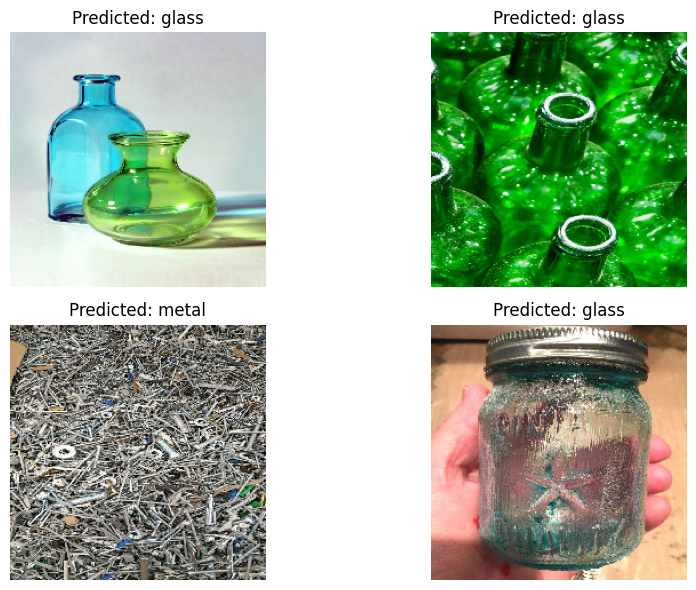

In [58]:
# predict one batch from your generator

images, labels = next(val_data)
show_predictions(images, model, class_names)